# 🌿 CropSense — Crop Disease Detection

**Dataset:** PlantVillage (54,305 images · 38 classes · 14 crop species)  
**Model:** EfficientNetB0 fine-tuned + Grad-CAM visualization  
**Goal:** Classify plant leaf images into healthy / diseased categories  

---

## 1. Install & Import

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
%pip install matplotlib seaborn scikit-learn grad-cam gradio Pillow tqdm

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, time, copy, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Dataset Setup

Download from Kaggle: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset  
Extract so that the folder structure is: `data/plantvillage/<class_name>/<image>.jpg`

In [5]:
DATA_DIR = Path(r'C:\Users\aarja\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3\plantvillage dataset\color') #dataset path
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4

# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(DATA_DIR)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f'Classes: {num_classes}')
print(f'Total images: {len(full_dataset)}')

# Save class names for inference
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

# 80/10/10 split
n = len(full_dataset)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val
train_set, val_set, test_set = random_split(full_dataset, [n_train, n_val, n_test])

# Apply transforms
train_set.dataset.transform = train_transforms
val_set.dataset.transform   = val_transforms
test_set.dataset.transform  = val_transforms

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

Classes: 38
Total images: 54305
Train: 43444 | Val: 5430 | Test: 5431


## 3. Visualize Sample Images

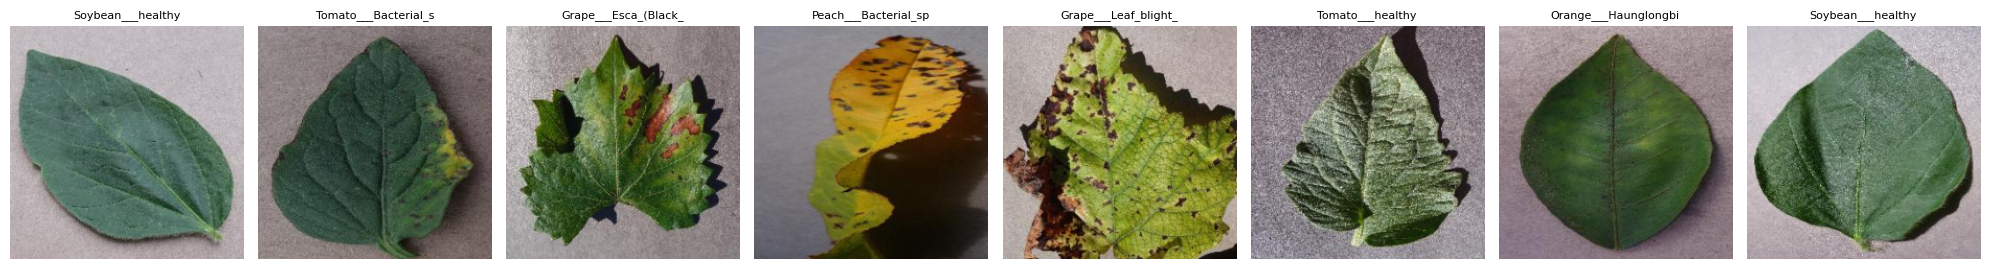

In [6]:
def imshow_batch(loader, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images = images * std + mean
    images = images.clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(20, 3))
    for i, ax in enumerate(axes):
        ax.imshow(images[i].permute(1, 2, 0))
        ax.set_title(class_names[labels[i]][:20], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('assets/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

imshow_batch(train_loader)

## 4. Build Model — EfficientNetB0 (Transfer Learning)

In [7]:
def build_model(num_classes, freeze_base=True):
    """
    EfficientNetB0 pretrained on ImageNet.
    We replace the classifier head for our 38-class problem.
    Phase 1: freeze base, train only head (fast)
    Phase 2: unfreeze top layers, fine-tune end-to-end
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    if freeze_base:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )
    return model.to(device)

model = build_model(num_classes, freeze_base=True)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\aarja/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:03<00:00, 5.60MB/s]


Total params:     4,682,914
Trainable params: 675,366


## 5. Training Loop

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, label='Phase'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0 #to store best one that was made and restore to that in case of overfitting
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        t0 = time.time()
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            loader = train_loader if phase == 'train' else val_loader
            running_loss, correct, total = 0.0, 0, 0

            with torch.set_grad_enabled(phase == 'train'):
                for images, labels in tqdm(loader, desc=f'{label} E{epoch+1} {phase}', leave=False):
                    images, labels = images.to(device), labels.to(device)
                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    running_loss += loss.item() * images.size(0)
                    _, preds = outputs.max(1)
                    correct += preds.eq(labels).sum().item()
                    total   += labels.size(0)

            epoch_loss = running_loss / total
            epoch_acc  = correct / total
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_weights = copy.deepcopy(model.state_dict())

        scheduler.step()
        print(f'[{label}] Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {history["train_loss"][-1]:.4f} Acc: {history["train_acc"][-1]:.4f} | '
              f'Val Loss: {history["val_loss"][-1]:.4f} Acc: {history["val_acc"][-1]:.4f} | '
              f'Time: {time.time()-t0:.1f}s')

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy: {best_acc:.4f}')
    return model, history

In [9]:
# Phase 1: Train only the classifier head (5 epochs, fast)
model, history1 = train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, label='Phase1')

[Phase1] Epoch 1/5 | Train Loss: 0.4448 Acc: 0.8698 | Val Loss: 0.1563 Acc: 0.9501 | Time: 256.0s


[Phase1] Epoch 2/5 | Train Loss: 0.2167 Acc: 0.9292 | Val Loss: 0.1307 Acc: 0.9595 | Time: 84.0s


[Phase1] Epoch 3/5 | Train Loss: 0.1725 Acc: 0.9417 | Val Loss: 0.1067 Acc: 0.9617 | Time: 81.8s


[Phase1] Epoch 4/5 | Train Loss: 0.1350 Acc: 0.9531 | Val Loss: 0.0823 Acc: 0.9729 | Time: 79.7s


[Phase1] Epoch 5/5 | Train Loss: 0.1155 Acc: 0.9611 | Val Loss: 0.0796 Acc: 0.9755 | Time: 78.3s

Best Val Accuracy: 0.9755


In [10]:
# Phase 2: Unfreeze all layers, fine-tune end to end (5 more epochs, lower LR)
for param in model.parameters():
    param.requires_grad = True

model, history2 = train_model(model, train_loader, val_loader, epochs=5, lr=1e-5, label='Phase2')

# Save model
torch.save(model.state_dict(), 'cropsense_efficientnet.pth')
print('Model saved.')

[Phase2] Epoch 1/5 | Train Loss: 0.0872 Acc: 0.9708 | Val Loss: 0.0493 Acc: 0.9858 | Time: 204.7s


[Phase2] Epoch 2/5 | Train Loss: 0.0583 Acc: 0.9796 | Val Loss: 0.0375 Acc: 0.9902 | Time: 204.6s


[Phase2] Epoch 3/5 | Train Loss: 0.0449 Acc: 0.9849 | Val Loss: 0.0395 Acc: 0.9891 | Time: 202.3s


[Phase2] Epoch 4/5 | Train Loss: 0.0384 Acc: 0.9870 | Val Loss: 0.0328 Acc: 0.9912 | Time: 203.0s


[Phase2] Epoch 5/5 | Train Loss: 0.0350 Acc: 0.9886 | Val Loss: 0.0307 Acc: 0.9913 | Time: 203.4s

Best Val Accuracy: 0.9913
Model saved.


## 6. Training Curves

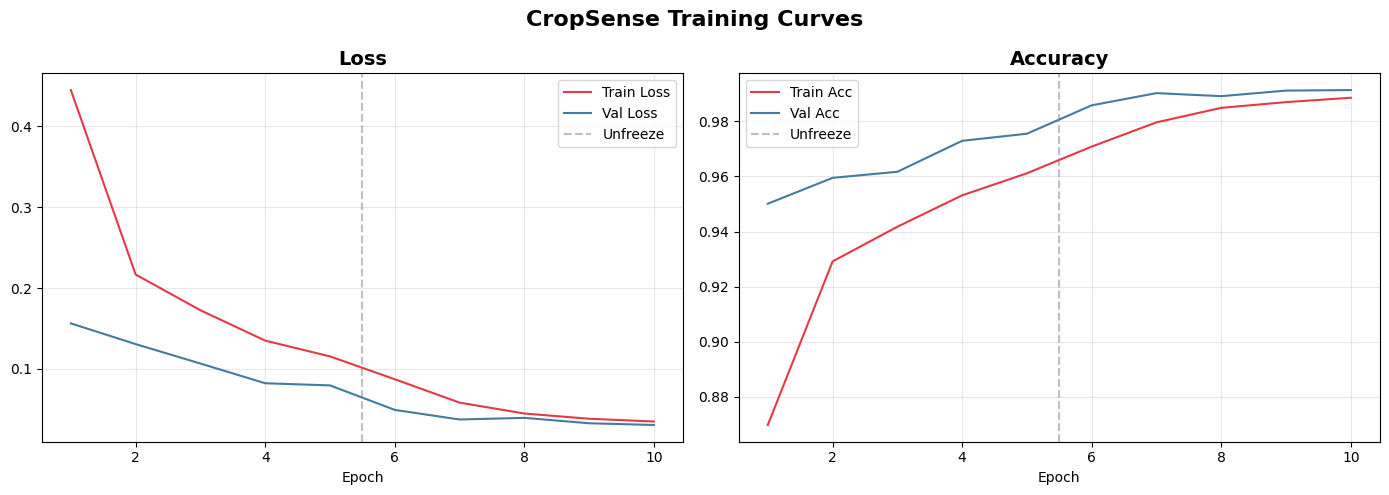

In [11]:
# Combine histories
history = {
    k: history1[k] + history2[k] for k in history1
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='#E63946')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#457B9D')
ax1.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze')
ax1.set_title('Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train Acc', color='#E63946')
ax2.plot(epochs_range, history['val_acc'],   label='Val Acc',   color='#457B9D')
ax2.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, label='Unfreeze')
ax2.set_title('Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CropSense Training Curves', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluation on Test Set

In [12]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

Evaluating: 100%|██████████| 170/170 [00:28<00:00,  5.87it/s]

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00        60
                                 Apple___Black_rot       1.00      1.00      1.00        77
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        34
                                   Apple___healthy       1.00      1.00      1.00       168
                               Blueberry___healthy       1.00      1.00      1.00       157
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       104
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00        90
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.86      0.86      0.86        49
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       125
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.93      0.

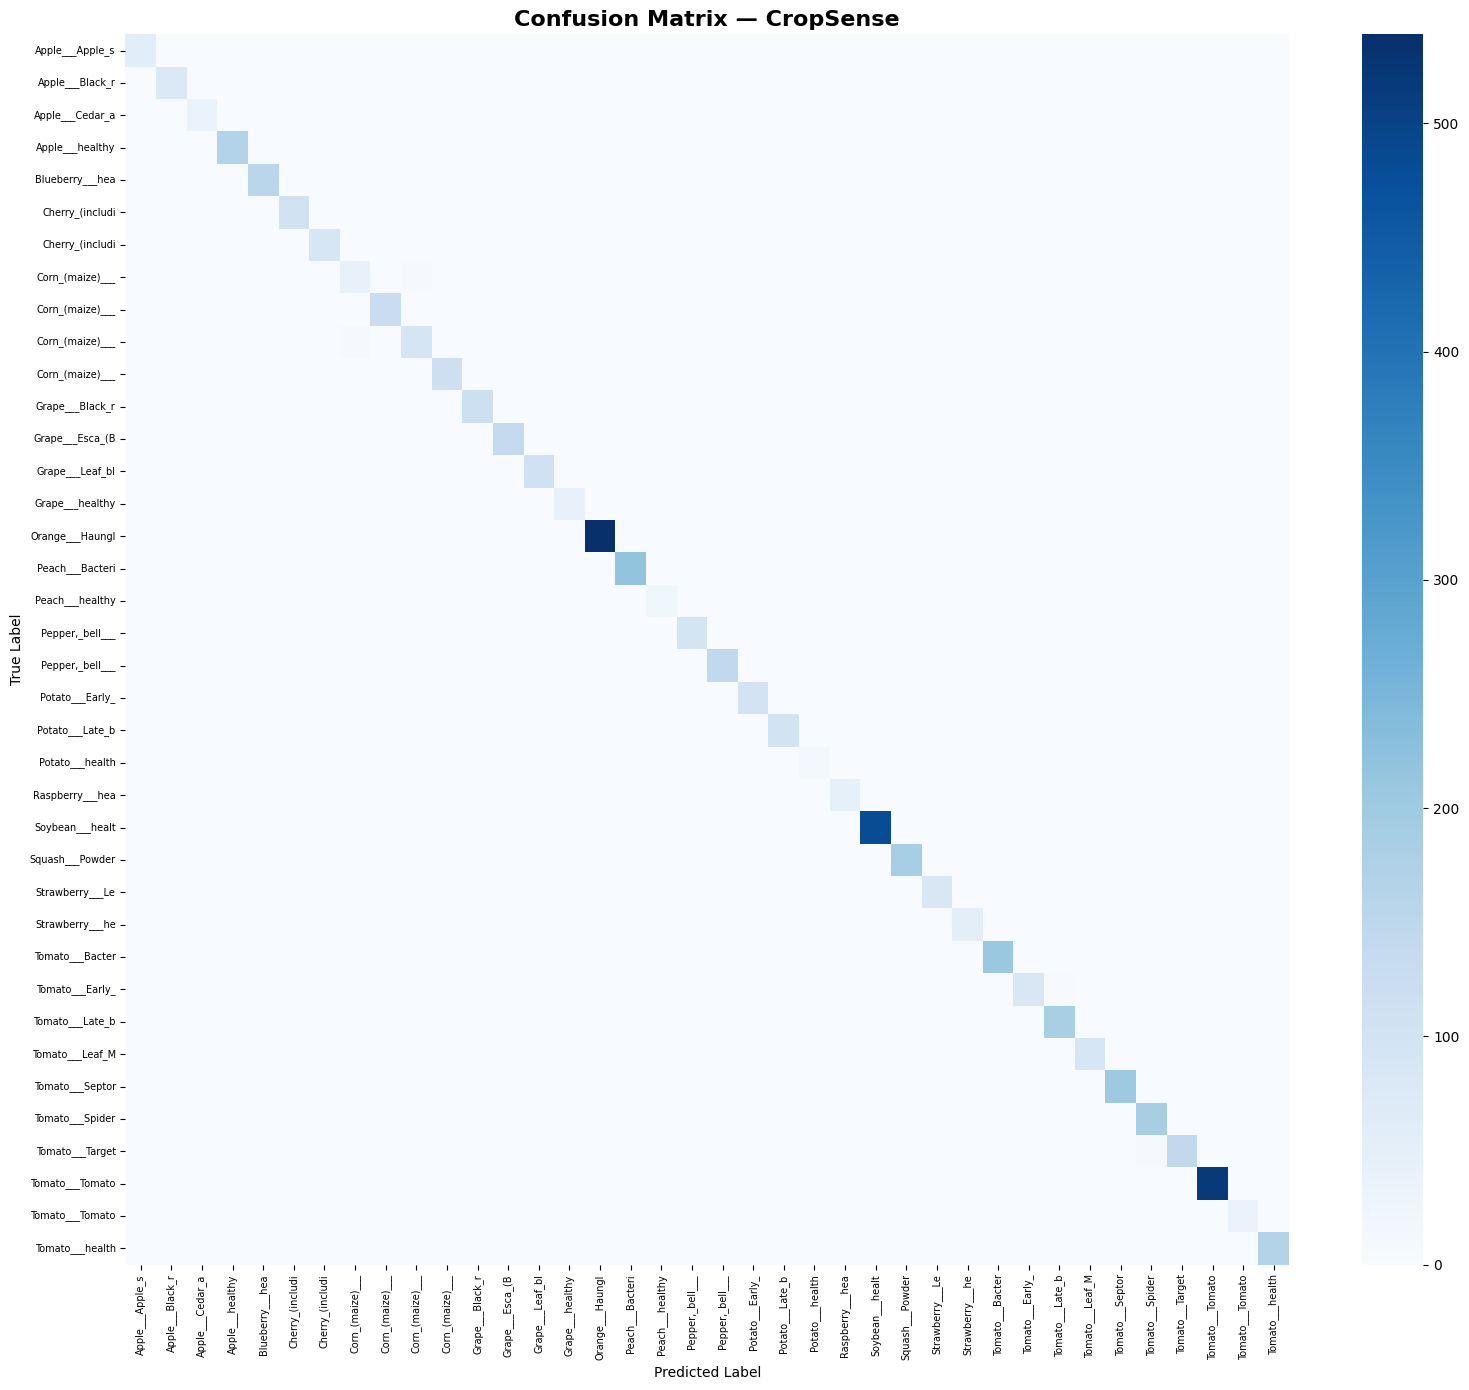

In [13]:
# Confusion matrix (top 15 classes for readability)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=[c[:15] for c in class_names],
            yticklabels=[c[:15] for c in class_names])
plt.title('Confusion Matrix — CropSense', fontsize=16, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Grad-CAM Visualization

Grad-CAM highlights *which region of the leaf* the model focused on when making its prediction — essential for explainability.

In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target the last conv layer of EfficientNetB0
target_layer = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

def visualize_gradcam(image_path, true_label=None):
    img = Image.open(image_path).convert('RGB').resize((224, 224))
    img_np = np.array(img) / 255.0

    tensor = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)
        conf, pred_idx = probs.max(1)

    pred_class = class_names[pred_idx.item()]
    confidence = conf.item() * 100

    grayscale_cam = cam(input_tensor=tensor, targets=[ClassifierOutputTarget(pred_idx.item())])
    cam_image = show_cam_on_image(img_np.astype(np.float32), grayscale_cam[0], use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_np); axes[0].set_title('Input Image', fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(cam_image)
    axes[1].set_title(f'Grad-CAM\nPred: {pred_class}\nConf: {confidence:.1f}%', fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig('assets/gradcam_example.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Prediction: {pred_class} ({confidence:.1f}% confidence)')

# Test on any image from your dataset
# visualize_gradcam('data/plantvillage/Tomato__Early_blight/some_image.jpg')
print('Grad-CAM ready. Call visualize_gradcam(image_path) with any leaf image.')

Grad-CAM ready. Call visualize_gradcam(image_path) with any leaf image.


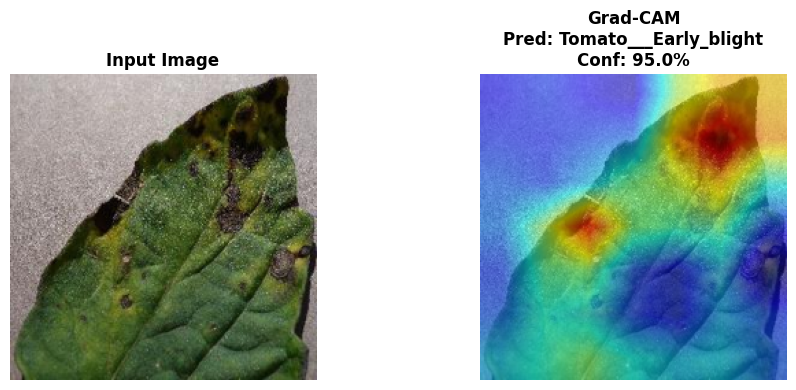

Prediction: Tomato___Early_blight (95.0% confidence)


In [17]:
visualize_gradcam(r'C:\Users\aarja\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3\plantvillage dataset\color\Tomato___Early_blight\0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG')

## 9. Launch Gradio Demo

In [ ]:
# Run app.py separately for the web demo:
# python app.py
print('Run: python app.py to launch the web interface')